<a href="https://colab.research.google.com/github/Yash-Yelave/Deep_Learning/blob/main/DL_PR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

def step_function(x):
    return 1 if x >= 0 else 0

def perceptron(x, w, b):
    y_in = np.dot(x, w) + b
    return step_function(y_in)

# Training Data for XOR Gate
xor_inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
xor_targets = np.array([0,1,1,0])

# Initialize random weights and bias
weights_xor = np.random.rand(2)
bias_xor = np.random.rand()

learning_rate = 0.1
epochs = 1000

print("\nAttempting to train a single perceptron for XOR Gate...\n")

for epoch in range(epochs):
    total_error = 0

    for i in range(len(xor_inputs)):
        x = xor_inputs[i]
        target = xor_targets[i]

        prediction = perceptron(x, weights_xor, bias_xor)

        error = target - prediction
        total_error += abs(error)

        if error != 0:
            weights_xor = weights_xor + learning_rate * error * x
            bias_xor = bias_xor + learning_rate * error

    if total_error == 0:
        print(f"Converged at epoch {epoch+1}")
        break

print(f"\nFinal Trained Weights after {epochs} epochs:", weights_xor)
print("Final Trained Bias after", epochs, "epochs:", bias_xor)

print("\nTesting Single Perceptron for XOR Gate after training:")
print("Input : Expected : Predicted")

for i in range(len(xor_inputs)):
    x = xor_inputs[i]
    target = xor_targets[i]
    prediction = perceptron(x, weights_xor, bias_xor)

    print(f"{x} : {target} : {prediction}")

print("\nSingle perceptron fails to learn XOR because XOR is not linearly separable.")


Attempting to train a single perceptron for XOR Gate...


Final Trained Weights after 1000 epochs: [-0.08069478  0.03067775]
Final Trained Bias after 1000 epochs: 0.04642091841039564

Testing Single Perceptron for XOR Gate after training:
Input : Expected : Predicted
[0 0] : 0 : 1
[0 1] : 1 : 1
[1 0] : 1 : 0
[1 1] : 0 : 0

Single perceptron fails to learn XOR because XOR is not linearly separable.


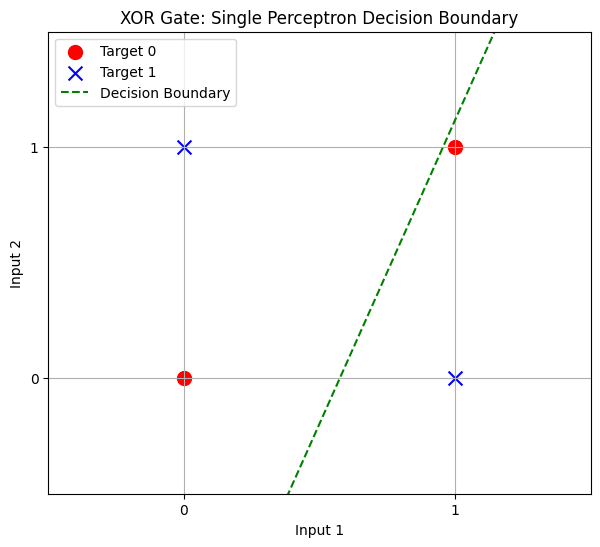

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

xor_inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
xor_targets = np.array([0,1,1,0])

plt.figure(figsize=(7,6))

for i in range(len(xor_inputs)):
    point = xor_inputs[i]
    target = xor_targets[i]

    if target == 0:
        plt.scatter(point[0], point[1], color='red', marker='o', s=100, label='Target 0' if i==0 else "")
    else:
        plt.scatter(point[0], point[1], color='blue', marker='x', s=100, label='Target 1' if i==1 else "")

# Decision Boundary
if weights_xor[1] != 0:
    x_vals = np.linspace(-0.5, 1.5, 100)
    y_vals = (-weights_xor[0] * x_vals - bias_xor) / weights_xor[1]
    plt.plot(x_vals, y_vals, 'g--', label='Decision Boundary')
else:
    if weights_xor[0] != 0:
        plt.axvline(x=-bias_xor / weights_xor[0], color='green', linestyle='--')

plt.title('XOR Gate: Single Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')

plt.xlim(-0.5,1.5)
plt.ylim(-0.5,1.5)

plt.xticks([0,1])
plt.yticks([0,1])

plt.grid(True)
plt.legend()

plt.show()